
# 12. 사령탑: 모자란 것을 보고 부품 부르기

**문제 세 종류** (종류는 알려 주지 않음):

| 종류 | 질문 | 기준 문의 열쇠 | 필요한 부품 |
|---|---|---|---|
| 신뢰만 | 기준 문 자체 | 사람들 말로만 | 신뢰 부품 |
| 생각만 | 고리 끝 문 | 안내판이 알려 줌 | 생각 루프 |
| **둘 다** | 고리 끝 문 | 사람들 말로만 | 신뢰 → 생각 |

- 학습에는 **"신뢰만", "생각만"만** 나온다. "둘 다"는 시험에 처음 나온다.
- 신뢰 부품에 한 번 물을 때마다 **−0.05**다.

**사령탑** (1,249개): 생각 루프가 먼저 생각한다. 그다음 사령탑이 기준 문마다 **무엇이 모자라나**를 본다. 특징은 이 문이 질문한 문과 이어져 있는가, 이 문의 열쇠를 아는가, 답을 아는가다. 그리고 물을지 정한다. 결과 점수만으로 배운다.

**통째 사령탑**(비교): 같은 정보를 보고 계획 하나를 고른다. 계획은 안 물음 / 질문한 문에 물음 / 셋 다 물음이다.


In [1]:

import json
import numpy as np
import matplotlib.pyplot as plt
from cognitive_lab import summary as S
from cognitive_lab import viz as V
V.setup()
SEEDS = (42, 43, 44)
TYPES = [("T", "신뢰만"), ("C", "생각만"), ("TC", "둘 다 (처음 봄)")]
runs = {s: json.loads((S.RESULTS / f"world-v7_router_seed-{s}.json").read_text(encoding="utf-8")) for s in SEEDS}
first = json.loads((S.RESULTS / "archive" / "world-v7_router_seed-42_identity-feature.json").read_text(encoding="utf-8"))
for s in SEEDS:
    print(s, {k: (v["router"], v["whole_router"], v["ideal_routing"]) for k, v in runs[s]["by_type"].items()})


42 {'T': (0.3926, 0.3926, 0.3926), 'C': (1.0, 1.0, 1.0), 'TC': (0.4109, 0.0, 0.4109)}
43 {'T': (0.4364, 0.4364, 0.4364), 'C': (1.0, 1.0, 1.0), 'TC': (0.3888, 0.0, 0.3888)}
44 {'T': (0.3698, 0.3698, 0.3698), 'C': (1.0, 1.0, 1.0), 'TC': (0.3364, 0.0, 0.3364)}



## 1. 처음 보는 조합에서 사령탑만 두 부품을 이었다

점선은 구조를 다 아는 이상적 라우팅이다(기준 문 열쇠를 모르면 닻에만 묻기).


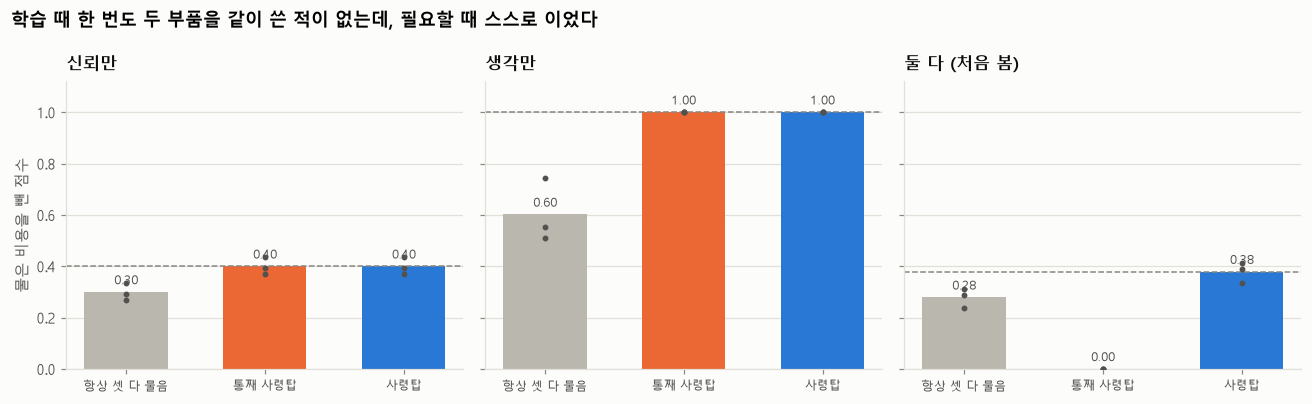

In [2]:

arms = [("항상 셋 다 물음", "ask_all", V.NEUTRAL), ("통째 사령탑", "whole_router", V.ORANGE), ("사령탑", "router", V.BLUE)]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.7), sharey=True)
for ax, (kind, label) in zip(axes, TYPES):
    x = np.arange(len(arms))
    for i, (name, key, color) in enumerate(arms):
        values = [runs[s]["by_type"][kind][key] for s in SEEDS]
        ax.bar(i, np.mean(values), width=0.6, color=color)
        ax.scatter([i] * 3, values, color=V.TEXT_SECONDARY, s=8, zorder=3)
        ax.text(i, np.mean(values) + 0.03, f"{np.mean(values):.2f}", ha="center", fontsize=8.5, color=V.TEXT_SECONDARY)
    ideal = np.mean([runs[s]["by_type"][kind]["ideal_routing"] for s in SEEDS])
    ax.axhline(ideal, color=V.MUTED, ls="--", lw=1)
    ax.set_xticks(x, [a[0] for a in arms], fontsize=8)
    ax.set_ylim(0, 1.12)
    ax.grid(axis="x", visible=False)
    ax.set_title(label, fontsize=11, pad=8)
axes[0].set_ylabel("물은 비용을 뺀 점수")
fig.suptitle("학습 때 한 번도 두 부품을 같이 쓴 적이 없는데, 필요할 때 스스로 이었다", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()



## 2. 1차 실패: "정체"를 보면 혼동이 생긴다

1차 사령탑은 "이 기준 문이 질문한 문인가"도 봤다. 학습("신뢰만")에서는 "이어져 있고 열쇠를 모름"과 "질문한 문 자체"가 항상 같이 나온다. 그래서 사령탑은 "질문한 문이면 묻는다"로 배웠고, "둘 다" 문제에서 한 번도 묻지 않았다(seed 42).


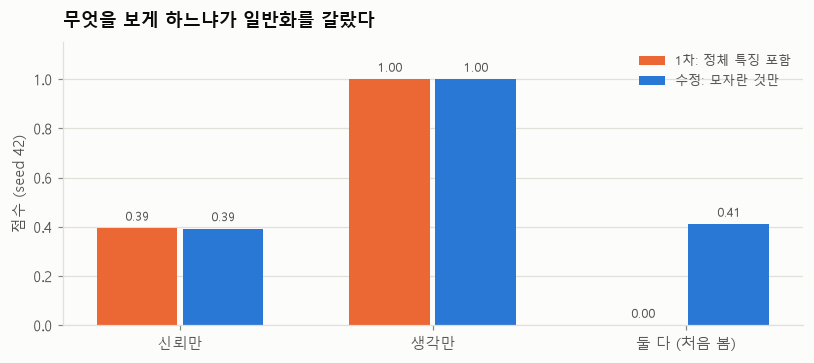

In [3]:

fig, ax = plt.subplots(figsize=(7.5, 3.4))
labels = [l for _, l in TYPES]
v1 = [first["by_type"][k]["router"] for k, _ in TYPES]
v2 = [runs[42]["by_type"][k]["router"] for k, _ in TYPES]
x = np.arange(3)
ax.bar(x - 0.17, v1, width=0.32, color=V.ORANGE, label="1차: 정체 특징 포함")
ax.bar(x + 0.17, v2, width=0.32, color=V.BLUE, label="수정: 모자란 것만")
for xi, a, b in zip(x, v1, v2):
    ax.text(xi - 0.17, a + 0.03, f"{a:.2f}", ha="center", fontsize=8.5, color=V.TEXT_SECONDARY)
    ax.text(xi + 0.17, b + 0.03, f"{b:.2f}", ha="center", fontsize=8.5, color=V.TEXT_SECONDARY)
ax.set_xticks(x, labels)
ax.set_ylim(0, 1.15)
ax.grid(axis="x", visible=False)
ax.legend(fontsize=8.5, frameon=False, loc="upper right")
ax.set_ylabel("점수 (seed 42)")
ax.set_title("무엇을 보게 하느냐가 일반화를 갈랐다", pad=10)
fig.tight_layout()
plt.show()



## 3. 정리

- **졸업.** 처음 보는 "둘 다" 문제에서 사령탑 점수(0.411 / 0.389 / 0.336)는 이상적 라우팅과 같다. 통째 사령탑은 0.000이다.
- 사령탑은 "둘 다" 문제에서 닻에 100% 물었고, 다른 기준 문에는 한 번도 묻지 않았다. "신뢰만"과 "생각만"에서도 이상적 라우팅과 같다.
- **교훈**: 올바른 상태 특징이 있으면 라우팅 규칙 자체는 단순하다("이어져 있고 모르면 묻기"). 어려운 것은 무엇을 보게 하느냐였다.
  - 겉모양을 보면 혼동이 생긴다(설계 단계에서 발견).
  - 정체 특징을 섞어도 혼동이 생긴다(1차 실패).
  - **"무엇이 모자라나"만 보게 해야** 처음 보는 조합으로 일반화했다.
- 한계: "이어져 있는가"는 생각 루프의 연결 그래프에서 사람이 짠 계산으로 뽑는다(틀). 부품이 셋뿐이고, 묻는 단위도 사람이 정했다.
